# Month-to-month carries most of the leavers

The contract has three phrases: `Month-to-month`, `One year`, and `Two year`.

| Contract | Customers | Leavers | Leave rate |
|---|---:|---:|---:|
| Month-to-month | 3875 | 1655 | $331/775$ |
| One year | 1473 | 166 | $166/1473$ |
| Two year | 1695 | 48 | $16/565$ |

The three counts add to the whole file:

$$
3875 + 1473 + 1695 = 7043,
\qquad
1655 + 166 + 48 = 1869.
$$

And $1655/3875 = 331/775$, while $48/1695 = 16/565$. Of every leaver in the file, 1655 are on a month-to-month contract.


In [1]:
# Locate the telco table beside this notebook, or under the course root.
import csv
from pathlib import Path

def data_path():
    here = Path.cwd()
    name = "Telco-Customer-Churn.csv"
    for folder in [here, *here.parents]:
        nested = folder / "17-Customer Churn" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists():
            return direct
    raise FileNotFoundError(name)

def read_customers():
    with data_path().open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))
# Contract counts, and the reduced leave rates.
from fractions import Fraction

rows = read_customers()
order = ("Month-to-month", "One year", "Two year")
expected = {
    "Month-to-month": (3875, 1655, Fraction(331, 775)),
    "One year": (1473, 166, Fraction(166, 1473)),
    "Two year": (1695, 48, Fraction(16, 565)),
}
for name in order:
    chosen = [row for row in rows if row["Contract"] == name]
    left = sum(row["Churn"] == "Yes" for row in chosen)
    rate = Fraction(left, len(chosen))
    print(name, len(chosen), left, rate)
    count, leavers, reduced = expected[name]
    assert (len(chosen), left, rate) == (count, leavers, reduced)
assert sum(expected[name][0] for name in order) == 7043
assert sum(expected[name][1] for name in order) == 1869


Month-to-month 3875 1655 331/775
One year 1473 166 166/1473
Two year 1695 48 16/565


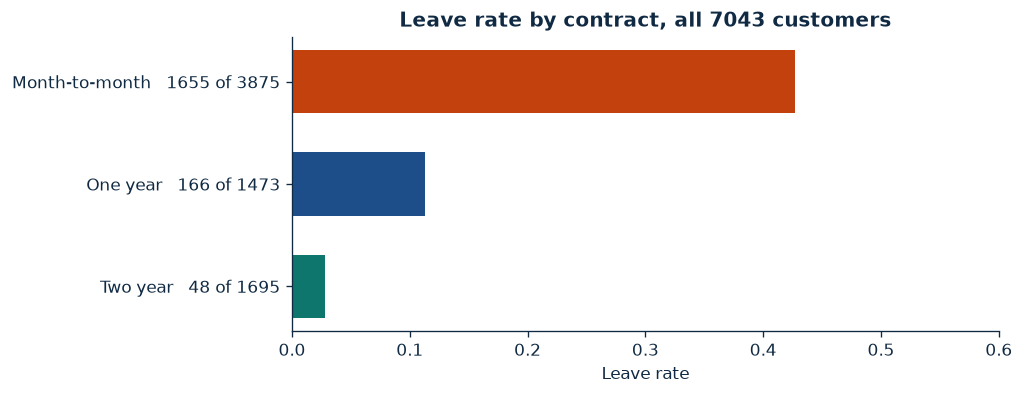

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
    "axes.titlecolor": "#102a43",
})
# Leave rate by contract. Month-to-month is the clay bar.
from fractions import Fraction
labels = [
    "Month-to-month   1655 of 3875",
    "One year   166 of 1473",
    "Two year   48 of 1695",
]
rates = [
    float(Fraction(1655, 3875)),
    float(Fraction(166, 1473)),
    float(Fraction(48, 1695)),
]
colors = ["#c2410c", "#1d4e89", "#0f766e"]
positions = [2, 1, 0]
figure, axis = plt.subplots(figsize=(8.6, 3.4))
axis.barh(positions, rates, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 0.6)
axis.set_xlabel("Leave rate")
axis.set_title("Leave rate by contract, all 7043 customers")
figure.tight_layout()


## Pitfall

$331/775$ is about 0.427. Inside the month-to-month group, staying is still the larger count: $3875 - 1655 = 2220$ stay. A cut that flags a customer whenever the group's rate exceeds $1/2$ leaves this group unflagged. The rate is still far above the two-year rate $16/565$.

## Summary

1655 of 1869 leavers are month-to-month. The leave rates are $331/775$, $166/1473$, and $16/565$.
